This notebook calcuates the MWs, and plots their distribution, to be used as a proxy for the total number of bonds a molecule can form. 

In [23]:
from pathlib import Path
import os
from functools import lru_cache
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer

from rdkit import Chem
from rdkit.Chem import Descriptors

from prob.interactions.interaction_data import load_ident_activity_mapping
from prob.prob_plots import plot_dist_with_log

In [2]:
mapping = load_ident_activity_mapping()
mapping.head(2)

,ident_processed,smiles,y_processed,ident,compound_structures.canonical_smiles,activities.standard_value,activity_id,similar.klifs_structure_id
0,0,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,5.148742,0,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,5.148742,32335,5326
1,17,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1CCC...,6.000000,17,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1CCC...,6.000000,40693,5326


In [3]:
@lru_cache(maxsize=200_000)     # to not calculate MW for same SMILES multiple times
def mw_from_smiles(smiles: str) -> float:
    if not isinstance(smiles, str) or not smiles:
        return float("nan")
    mol = Chem.MolFromSmiles(smiles)
    return Descriptors.MolWt(mol) if mol is not None else float("nan")

Transforms

In [16]:
# def exp_transform_mw(df: pd.DataFrame, in_col: str, out_col: str, eps: float = 1e-3,
# ):
#     MW_MIN = df[in_col].quantile(0.01) 
#     lam = 1 / 100  # tune this

#     mw_eff = df[in_col].clip(lower=MW_MIN)
#     df[out_col] = 1 - np.exp(-lam * (mw_eff - MW_MIN))

#     df[out_col] = eps + (1 - eps) * df[out_col]
#     return df

transform = QuantileTransformer(
    output_distribution="uniform",
    n_quantiles=10000,
)

def _no_zeros(df, col, eps=1e-3):
    df[col] = eps + (1 - 2*eps) * df[col]
    return df

In [17]:
mws = pd.DataFrame()
mws["mw"] = mapping["smiles"].apply(mw_from_smiles)
print("Molecular weight statistics:")
print(mws["mw"].describe())


# Scale first, then inverse
mws["mw_01"] = transform.fit_transform(mws[["mw"]])
mws = _no_zeros(mws, "mw_01")
mws["mw_01_inv"] = 1 / mws["mw_01"]
print("\nMolecular weight after scaling to [0, 1]:")
print(mws["mw_01"].describe())

# Inverse first, then scale to [0.1, 100]
mws["inv_mw"] = 1 / mws["mw"]
mws["inv_mw_01"] = transform.fit_transform(mws[["inv_mw"]])
mws = _no_zeros(mws, "inv_mw_01")
print("\nInverse of molecular weight after scaling to [0, 1]:")
print(mws["inv_mw_01"].describe())




Molecular weight statistics:
count    119522.000000
mean        440.439277
std          92.278931
min          76.124000
25%         378.404000
50%         438.532000
75%         498.930500
max        1861.731000
Name: mw, dtype: float64

Molecular weight after scaling to [0, 1]:
count    119522.000000
mean          0.500612
std           0.288747
min           0.001000
25%           0.248629
50%           0.501647
75%           0.750096
max           0.999000
Name: mw_01, dtype: float64

Inverse of molecular weight after scaling to [0, 1]:
count    119522.000000
mean          0.501102
std           0.288948
min           0.001000
25%           0.249201
50%           0.501647
75%           0.752846
max           0.999000
Name: inv_mw_01, dtype: float64


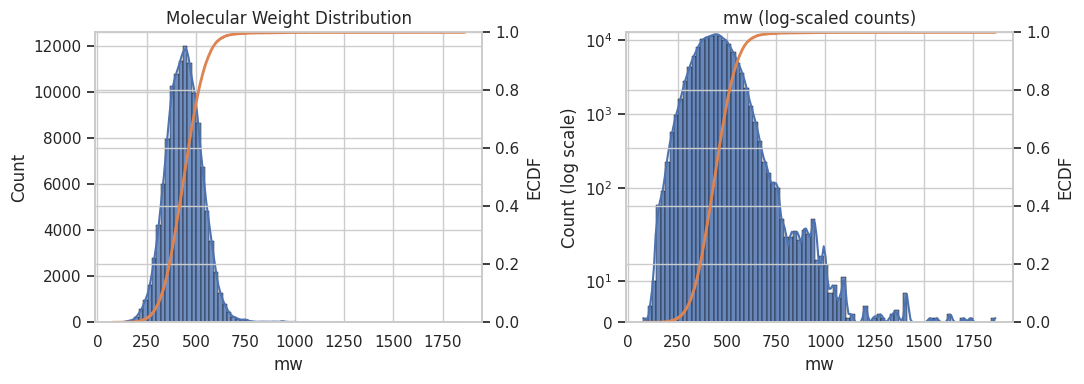

In [18]:
plot_dist_with_log(mws, col="mw", title="Molecular Weight Distribution", show_ecdf=True, 
                   kde=True,
                   context_overwrite="notebook",)

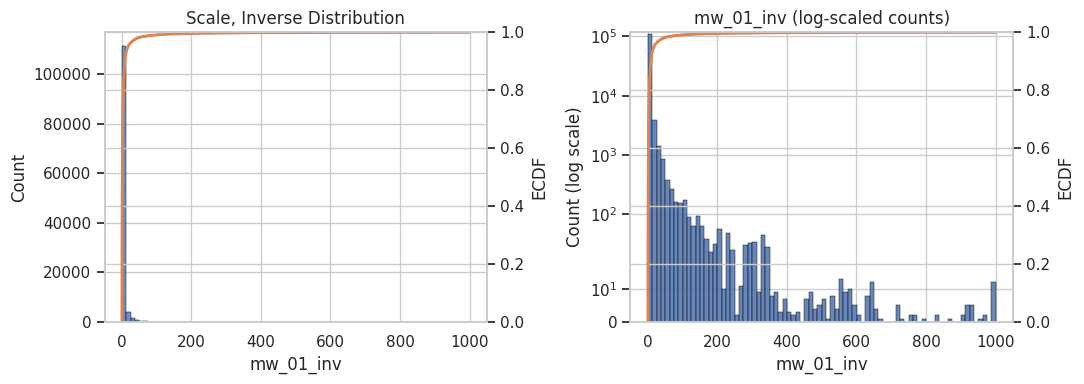

In [19]:
plot_dist_with_log(mws, col="mw_01_inv", title="Scale, Inverse Distribution", show_ecdf=True, context_overwrite="notebook",)

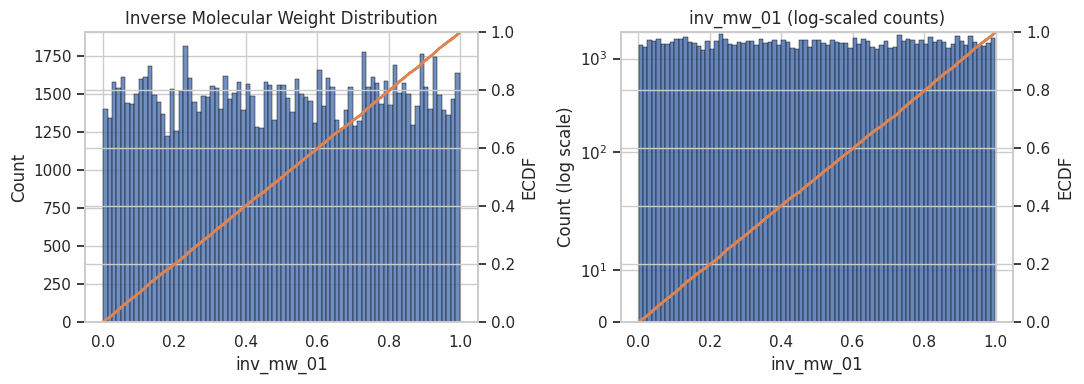

In [20]:
plot_dist_with_log(mws, col="inv_mw_01", title="Inverse Molecular Weight Distribution", show_ecdf=True, context_overwrite="notebook",)

Save as CSV

Add ident and smiles

In [ ]:
mws = mw.merge(mws, mapping[["smiles", "idents"]], left_index=True, right_index=True)

In [27]:
# messy root path handling, but this is just a helper file and not a module, so it's fine for now
_ROOT = Path(".").absolute().parents[1]
mws.to_csv(_ROOT / "data/probing/helpers/mws.csv", index=False)